In [1]:
!kaggle datasets download msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 226MB/s]



In [2]:
import zipfile
zip_path = "/content/fer2013.zip"
extract_path = "/content/fer2013"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [3]:
#import libraries
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn

In [4]:
batch_size = 64

img_size = 48
patch_size = 6

num_channels = 1

num_patches = (img_size // patch_size) ** 2

num_heads = 4

embed_dim = 128

mlp_dim = 256

transformer_units = 6

dropout = 0.1

In [5]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(
        48,
        scale=(0.8, 1.0)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [6]:
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [7]:
#load dataset
trainset = torchvision.datasets.ImageFolder(root='/content/fer2013/train',transform=train_transform)
valset = torchvision.datasets.ImageFolder(root='/content/fer2013/test' ,transform=test_transform)

In [8]:
#create train and val batches
train_data = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True)
val_data = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                          shuffle=False)


In [9]:
images, labels = next(iter(train_data))
images.shape
labels

tensor([1, 4, 4, 3, 4, 2, 5, 5, 3, 0, 4, 4, 3, 5, 2, 3, 0, 5, 2, 4, 0, 2, 5, 1,
        4, 4, 5, 2, 3, 0, 3, 4, 2, 4, 6, 4, 5, 5, 3, 5, 2, 2, 4, 5, 2, 4, 4, 6,
        3, 5, 0, 5, 2, 0, 0, 2, 2, 4, 3, 5, 5, 5, 3, 2])

In [10]:
class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2)
        x = x.transpose(1,2)
        return x

In [11]:
patch_embed=PatchEmbedding()
embedding=patch_embed(images)
embedding.shape

torch.Size([64, 64, 128])

In [31]:
class TransformerArchitecture(nn.Module):
    def __init__(self):
        super().__init__()

        # Layer Normalization
        self.layer_norm_1 = nn.LayerNorm(embed_dim)

        # Multi-Head Self Attention
        self.self_attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=0.1,
            batch_first=True
        )

        # Layer Normalization
        self.layer_norm_2 = nn.LayerNorm(embed_dim)

        # Feed Forward Network
        self.multi_layer_perceptron = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(0.1)
        )

    def forward(self, x):

        # -------- Self Attention --------
        residual_1 = x

        normalized_x = self.layer_norm_1(x)

        attention_output, _ = self.self_attention(
            normalized_x,
            normalized_x,
            normalized_x
        )

        x = residual_1 + attention_output

        # -------- MLP --------
        residual_2 = x

        normalized_x = self.layer_norm_2(x)

        mlp_output = self.multi_layer_perceptron(normalized_x)

        x = residual_2 + mlp_output

        return x

In [32]:
class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embedding = PatchEmbedding()
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches+ 1, embed_dim))
        self.transformer_layers = nn.Sequential(*[TransformerArchitecture() for _ in range(transformer_units)])
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 7)
        )

    def forward(self,x):
        x = self.patch_embedding(x)
        B = x.size(0)

        cls_tokens = self.cls_token.expand(B , -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.transformer_layers(x)
        x = x[:,0]
        x = self.mlp_head(x)
        return x

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VisionTransformer().to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()

In [34]:
device

device(type='cuda')

In [35]:
for epoch in range(10):
    model.train()
    total_loss = 0
    correct_epoch = 0
    total_epoch = 0
    print(f"\nEpoch {epoch+1}")

    for batch_idx, (images, labels) in enumerate(train_data):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()
        preds = outputs.argmax(dim=1)

        correct = (preds == labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)

        correct_epoch += correct
        total_epoch += labels.size(0)

        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx+1:3d}: Loss = {loss.item():.4f}, Accuracy = {accuracy:.2f}%")

    epoch_acc = 100.0 * correct_epoch / total_epoch
    print(f"==> Epoch {epoch+1} Summary: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}%")


Epoch 1
  Batch   1: Loss = 2.0764, Accuracy = 7.81%
  Batch 101: Loss = 1.7804, Accuracy = 20.31%
  Batch 201: Loss = 1.9394, Accuracy = 23.44%
  Batch 301: Loss = 1.8211, Accuracy = 20.31%
  Batch 401: Loss = 1.8007, Accuracy = 18.75%
==> Epoch 1 Summary: Total Loss = 806.7014, Accuracy = 24.58%

Epoch 2
  Batch   1: Loss = 1.6775, Accuracy = 25.00%
  Batch 101: Loss = 1.8144, Accuracy = 26.56%
  Batch 201: Loss = 1.8370, Accuracy = 29.69%
  Batch 301: Loss = 1.7015, Accuracy = 29.69%
  Batch 401: Loss = 1.6535, Accuracy = 32.81%
==> Epoch 2 Summary: Total Loss = 796.2046, Accuracy = 26.00%

Epoch 3
  Batch   1: Loss = 1.6892, Accuracy = 29.69%
  Batch 101: Loss = 1.7062, Accuracy = 28.12%
  Batch 201: Loss = 1.6563, Accuracy = 39.06%
  Batch 301: Loss = 1.5972, Accuracy = 39.06%
  Batch 401: Loss = 1.7987, Accuracy = 25.00%
==> Epoch 3 Summary: Total Loss = 770.2306, Accuracy = 30.61%

Epoch 4
  Batch   1: Loss = 1.9422, Accuracy = 21.88%
  Batch 101: Loss = 1.6983, Accuracy = 32.8

In [17]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_data:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100.0 * correct / total
print(f"\n==> Val Accuracy: {test_acc:.2f}%")



==> Val Accuracy: 25.31%


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

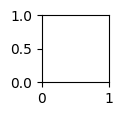

In [24]:
model.eval()
images, labels = next(iter(val_data))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

# Plot 10 test images with predictions
plt.figure(figsize=(12, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(images[i].squeeze(0), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()